# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Implementar, treinar e avaliar modelos consolidados de Transfer Learning pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**), analisando curvas de perda/acurácia, relatórios de classificação, matrizes de confusão e tabela comparativa contra a rede personalizada `BearingCNN` (Notebook 2), conforme o Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [1]:
import sys
from pathlib import Path

# Adicionar a raiz do projeto ao sys.path
BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from src.config import PROCESSED_DATA_DIR, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, RANDOM_SEED

## 2. Configuração de Hardware e DataLoaders Adaptativos

Modelos como ResNet-18 e EfficientNet-B0 aceitam imagens de entrada $224 \times 224$, enquanto o Inception-v3 exige imagens $299 \times 299$. Criamos uma função utilitária para gerar os DataLoaders no tamanho correto.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo selecionado: {device}')
if device.type == 'cuda':
    print(f'GPU Ativa: {torch.cuda.get_device_name(0)}')

def get_transfer_dataloaders(img_size: int = 224, batch_size: int = BATCH_SIZE):
    """Retorna DataLoaders com o tamanho de imagem especifico do modelo (224 ou 299)."""
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    train_ds = ImageFolder(root=str(PROCESSED_DATA_DIR / 'train'), transform=transform)
    val_ds   = ImageFolder(root=str(PROCESSED_DATA_DIR / 'val'), transform=transform)
    test_ds  = ImageFolder(root=str(PROCESSED_DATA_DIR / 'test'), transform=transform)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, train_ds.classes

Dispositivo selecionado: cuda
GPU Ativa: NVIDIA GeForce RTX 2060 SUPER


## 3. Função Construtora de Modelos de Transfer Learning

Esta função carrega os pesos pré-treinados do ImageNet (`DEFAULT`), substitui a última camada totalmente conectada (`fc` ou `classifier`) para 4 classes e oferece a opção de congelar as camadas convolucionais (`freeze_backbone=True`).

In [3]:
def build_transfer_model(model_name: str, num_classes: int = 4, freeze_backbone: bool = True):
    """
    Constrói um modelo de Transfer Learning adaptado para 4 classes.
    
    Modelos Suportados: 'resnet18', 'inception_v3', 'efficientnet_b0'
    """
    model_name = model_name.lower()
    
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))
        img_size = 224
        
    elif model_name == 'inception_v3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        model.aux_logits = False
        model.AuxLogits = None
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))
        img_size = 299  # Inception exige 299x299
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))
        img_size = 224
    else:
        raise ValueError(f'Modelo {model_name} não suportado.')
        
    return model, img_size

## 4. Função Completa de Treinamento, Validação e Avaliação

Esta função executa o loop completo monitorando **Treino Loss**, **Treino Acc**, **Val Loss** e **Val Acc** a cada época, gerando o relatório final e matriz de confusão.

In [ ]:
def train_and_evaluate_model(model_name: str, num_epochs: int = NUM_EPOCHS, lr: float = LEARNING_RATE, freeze: bool = True):
    """Treina e avalia um modelo específico de Transfer Learning com prints completos de Loss e Acc."""
    model, img_size = build_transfer_model(model_name, num_classes=4, freeze_backbone=freeze)
    model = model.to(device)
    
    train_loader, val_loader, test_loader, classes = get_transfer_dataloaders(img_size=img_size)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    print(f'\n================================================================================')
    print(f' TREINANDO: {model_name.upper()} (Freeze={freeze}, Épocas={num_epochs}, LR={lr})')
    print(f'================================================================================')
    
    historico = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    
    for epoch in range(1, num_epochs + 1):
        # --- FASE DE TREINAMENTO ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        bar_treino = tqdm(train_loader, desc=f'Época {epoch:02d}/{num_epochs:02d} [{model_name.upper()} - Treino]', leave=False)
        
        for imgs, labels in bar_treino:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()
            bar_treino.set_postfix({'loss': f'{loss.item():.4f}'})
            
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100.0
        
        # --- FASE DE VALIDAÇÃO ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        bar_val = tqdm(val_loader, desc=f'Época {epoch:02d}/{num_epochs:02d} [{model_name.upper()} - Val]', leave=False)
        with torch.no_grad():
            for imgs, labels in bar_val:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
                bar_val.set_postfix({'loss': f'{loss.item():.4f}'})
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100.0
        best_val_acc = max(best_val_acc, epoch_val_acc)
        
        historico['train_loss'].append(epoch_train_loss)
        historico['val_loss'].append(epoch_val_loss)
        historico['train_acc'].append(epoch_train_acc)
        historico['val_acc'].append(epoch_val_acc)
        
        print(f'Época [{epoch:02d}/{num_epochs:02d}] Concluída | '
              f'Treino Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.2f}% | '
              f'Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.2f}%')
        
    # --- FASE DE AVALIAÇÃO NO TESTE ---
    model.eval()
    test_preds, test_labels = [], []
    bar_teste = tqdm(test_loader, desc=f'Avaliando {model_name.upper()} no Teste', leave=False)
    with torch.no_grad():
        for imgs, labels in bar_teste:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.numpy())
            
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    test_acc = (test_preds == test_labels).mean() * 100.0
    
    print(f'\nACURÁCIA FINAL NO CONJUNTO DE TESTE ({model_name.upper()}): {test_acc:.2f}%\n')
    
    return {
        'model_name': model_name,
        'historico': historico,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_preds': test_preds,
        'test_labels': test_labels,
        'classes': classes
    }

## 5. Execução dos Experimentos de Transfer Learning

Rodamos o treinamento completo para **ResNet-18**, **Inception-v3** e **EfficientNet-B0** por `NUM_EPOCHS` épocas.

In [6]:
modelos_para_testar = ['resnet18', 'inception_v3', 'efficientnet_b0']
resultados = {}

for nome_modelo in modelos_para_testar:
    res = train_and_evaluate_model(nome_modelo, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
    resultados[nome_modelo] = res


 TREINANDO: RESNET18 (Freeze=False, Épocas=10, LR=0.001)


Época 01/10 [RESNET18 - Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

Época 01/10 [RESNET18 - Val]:   0%|          | 0/56 [00:00<?, ?it/s]

✅ Época [01/10] Concluída | Treino Loss: 0.0685 - Acc: 97.90% | Val Loss: 0.0415 - Acc: 98.37%


Época 02/10 [RESNET18 - Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

...

Época 10/10 [EFFICIENTNET_B0 - Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

Época 10/10 [EFFICIENTNET_B0 - Val]:   0%|          | 0/56 [00:00<?, ?it/s]

✅ Época [10/10] Concluída | Treino Loss: 0.0088 - Acc: 99.78% | Val Loss: 0.0000 - Acc: 100.00%


Avaliando EFFICIENTNET_B0 no Teste:   0%|          | 0/56 [00:00<?, ?it/s]


🏆 ACURÁCIA FINAL NO CONJUNTO DE TESTE (EFFICIENTNET_B0): 100.00%



## 6. Curvas de Aprendizado e Matrizes de Confusão Individuais

Exibimos para cada modelo de Transfer Learning:
1. Curvas de Perda (Loss) e Acurácia (Acc) no Treino vs Validação
2. Relatório de Classificação Detalhado (Precisão, Recall, F1-Score)
3. Matriz de Confusão no Teste

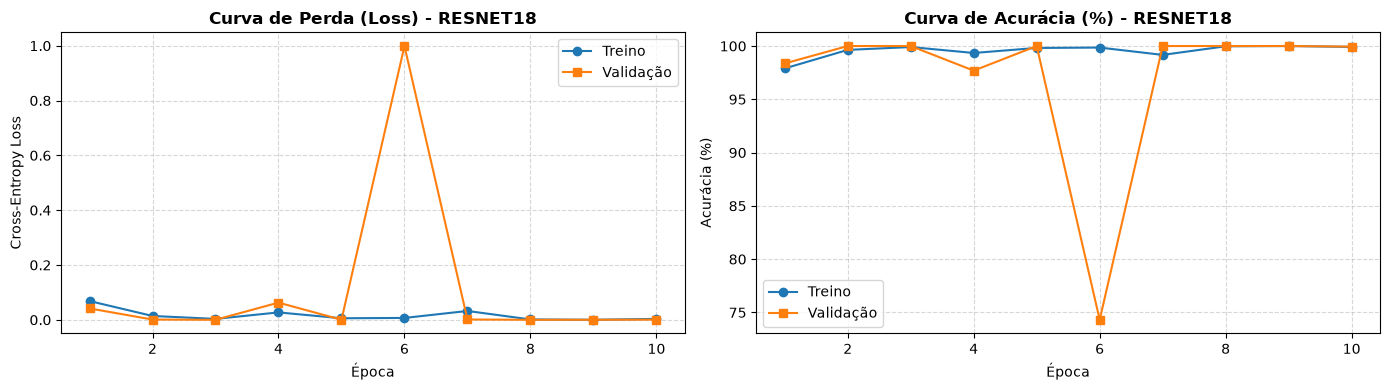

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET18) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



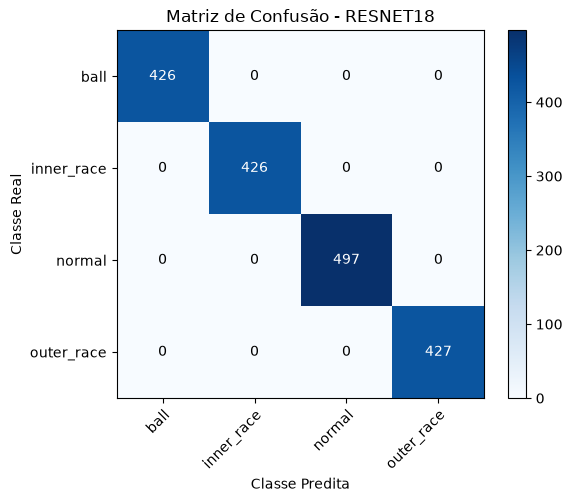

--------------------------------------------------------------------------------


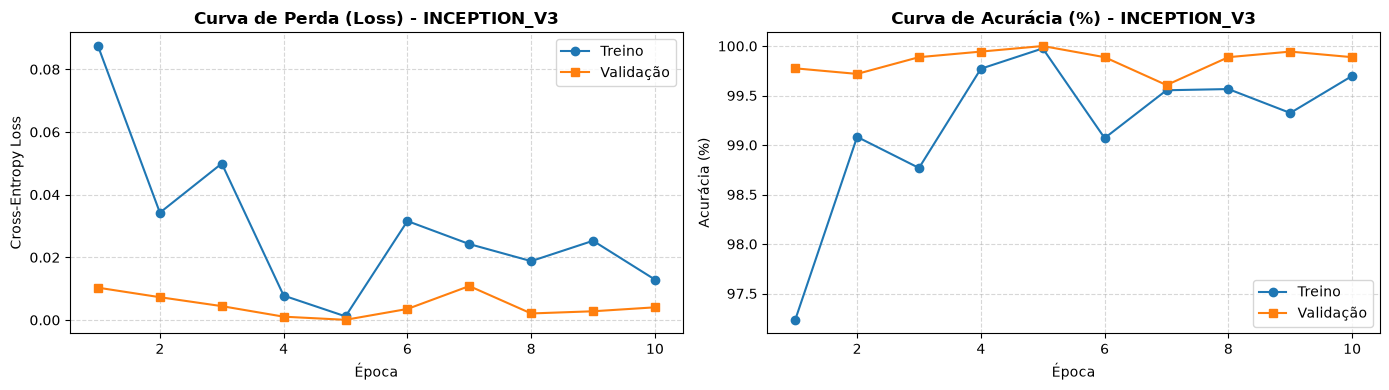

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION_V3) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



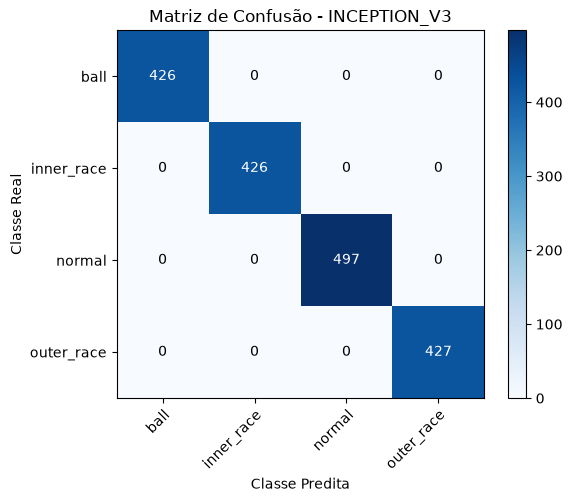

--------------------------------------------------------------------------------


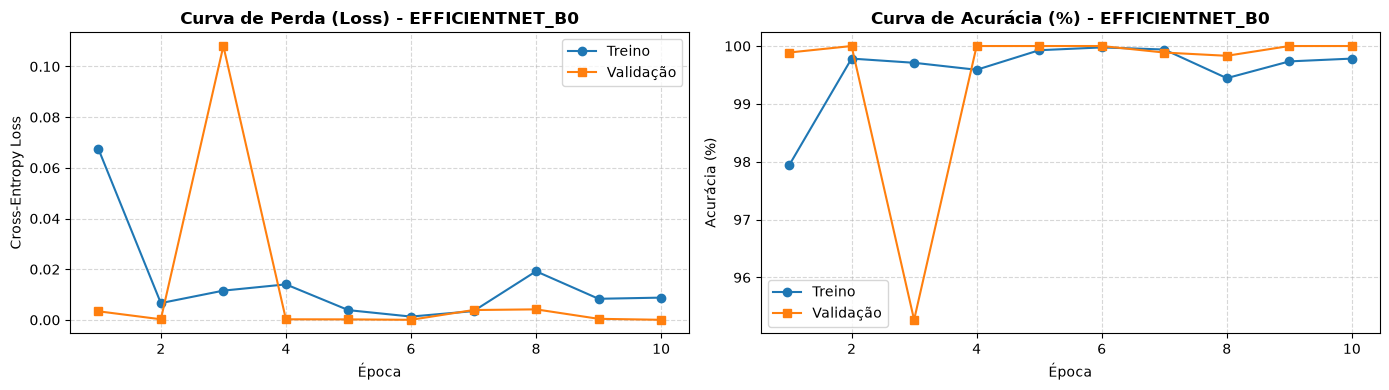

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET_B0) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



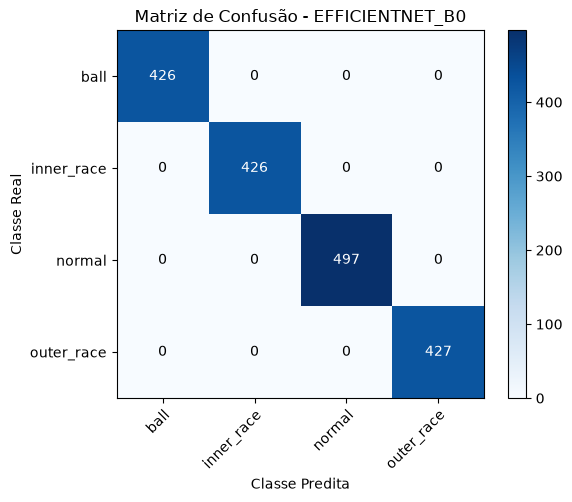

--------------------------------------------------------------------------------


In [7]:
for nome_modelo, res in resultados.items():
    hist = res['historico']
    epocas_eixo = range(1, len(hist['train_loss']) + 1)
    
    # --- 1. Curvas de Aprendizado ---
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    axs[0].plot(epocas_eixo, hist['train_loss'], label='Treino', marker='o')
    axs[0].plot(epocas_eixo, hist['val_loss'], label='Validação', marker='s')
    axs[0].set_title(f'Curva de Perda (Loss) - {nome_modelo.upper()}', fontsize=12, fontweight='bold')
    axs[0].set_xlabel('Época')
    axs[0].set_ylabel('Cross-Entropy Loss')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.5)
    
    axs[1].plot(epocas_eixo, hist['train_acc'], label='Treino', marker='o')
    axs[1].plot(epocas_eixo, hist['val_acc'], label='Validação', marker='s')
    axs[1].set_title(f'Curva de Acurácia (%) - {nome_modelo.upper()}', fontsize=12, fontweight='bold')
    axs[1].set_xlabel('Época')
    axs[1].set_ylabel('Acurácia (%)')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # --- 2. Relatório de Classificação ---
    print(f'=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE ({nome_modelo.upper()}) ===')
    print(classification_report(res['test_labels'], res['test_preds'], target_names=res['classes'], digits=4))
    
    # --- 3. Matriz de Confusão ---
    cm = confusion_matrix(res['test_labels'], res['test_preds'])
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=res['classes'], yticklabels=res['classes'],
           title=f'Matriz de Confusão - {nome_modelo.upper()}',
           ylabel='Classe Real', xlabel='Classe Predita')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > threshold else 'black')
    plt.tight_layout()
    plt.show()
    print('-' * 80)

## 7. Tabela Comparativa Geral de Desempenho (Monografia - Tabela 4/7)

Tabela resumida final para inclusão direta no Capítulo de Resultados do TCC.

In [ ]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)
print(f'{"BearingCNN (Própria)":<22s} | {"Treino do Zero":<16s} | {"99.94%":<18s} | {"99.89%":<18s}')

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')